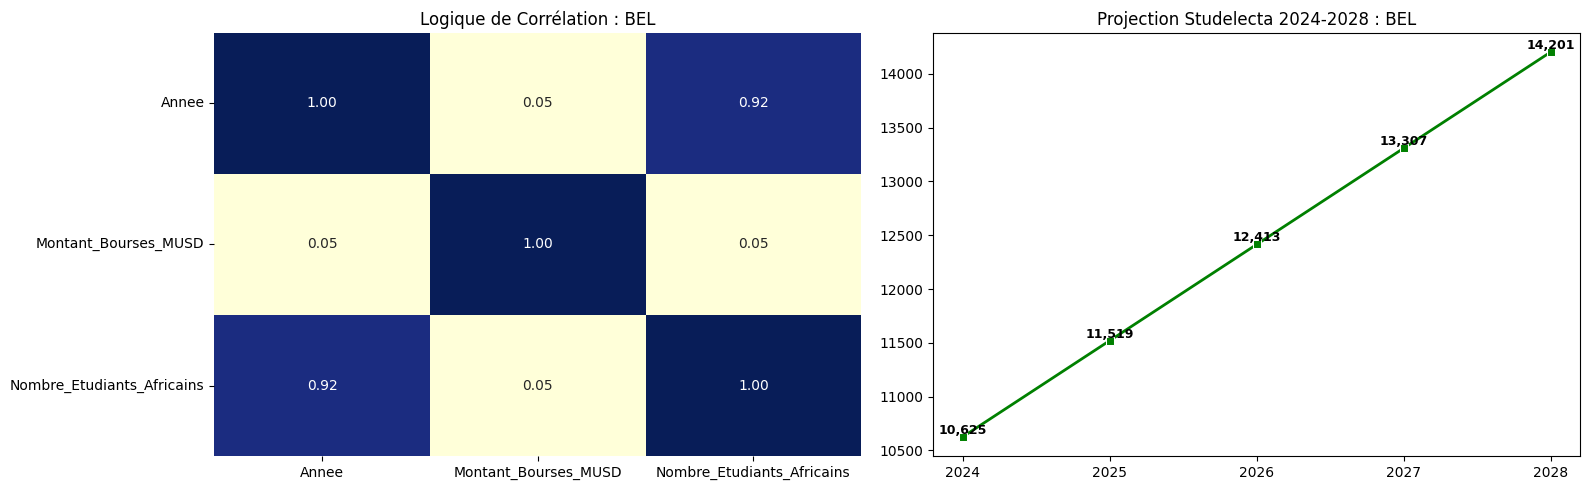

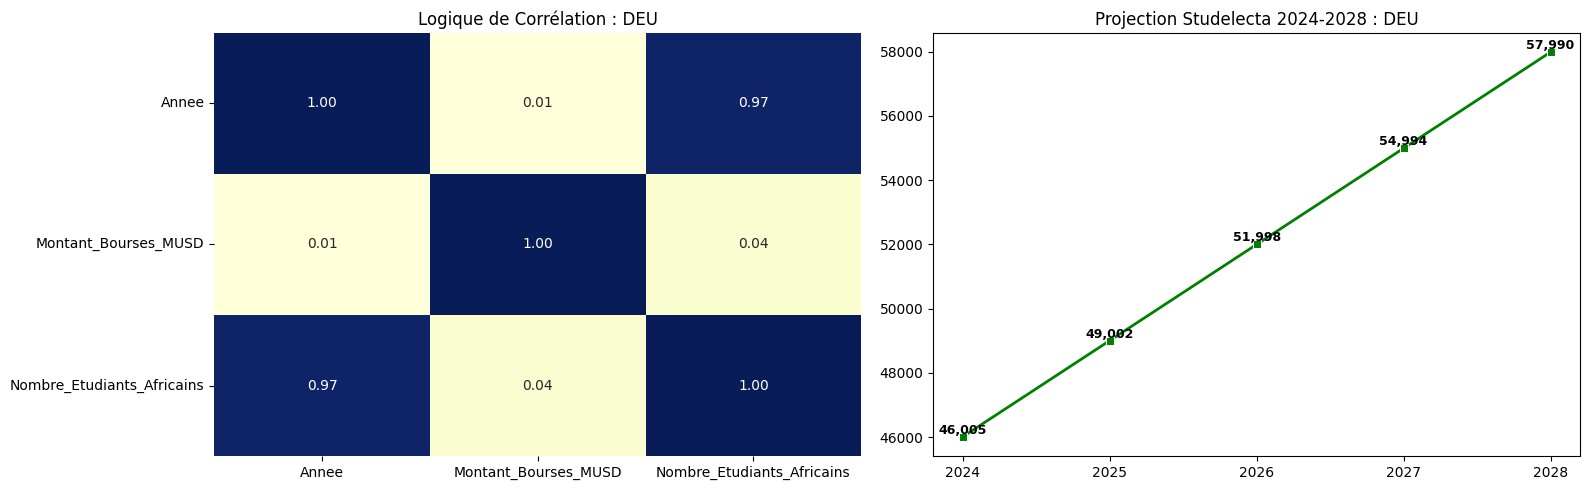

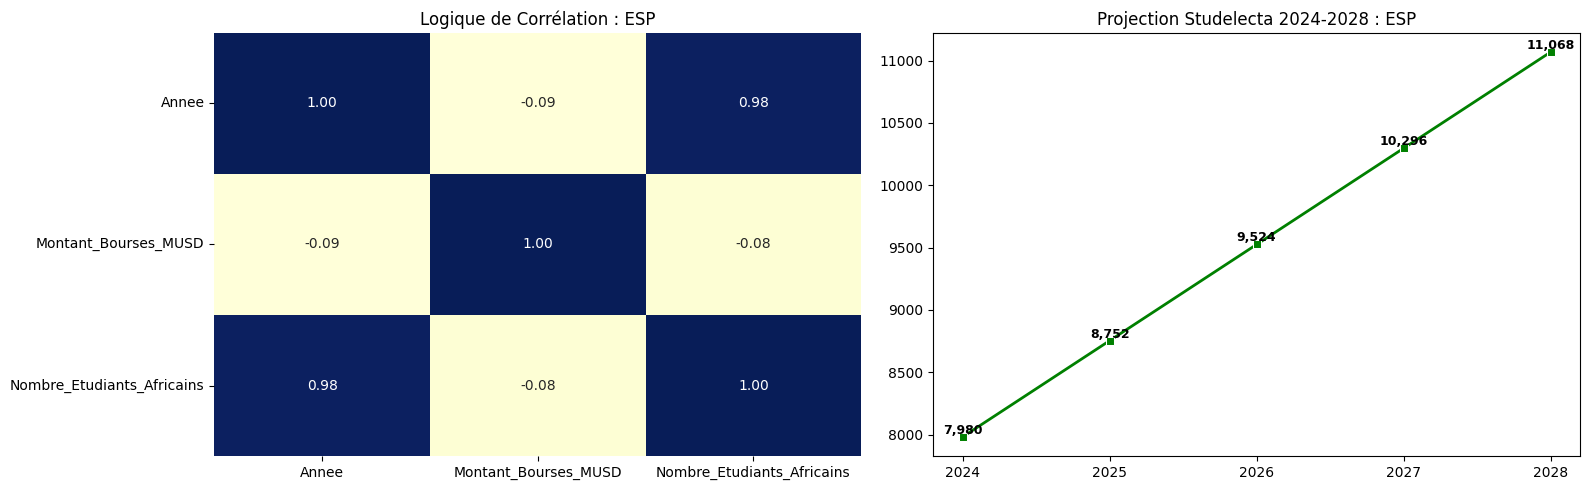

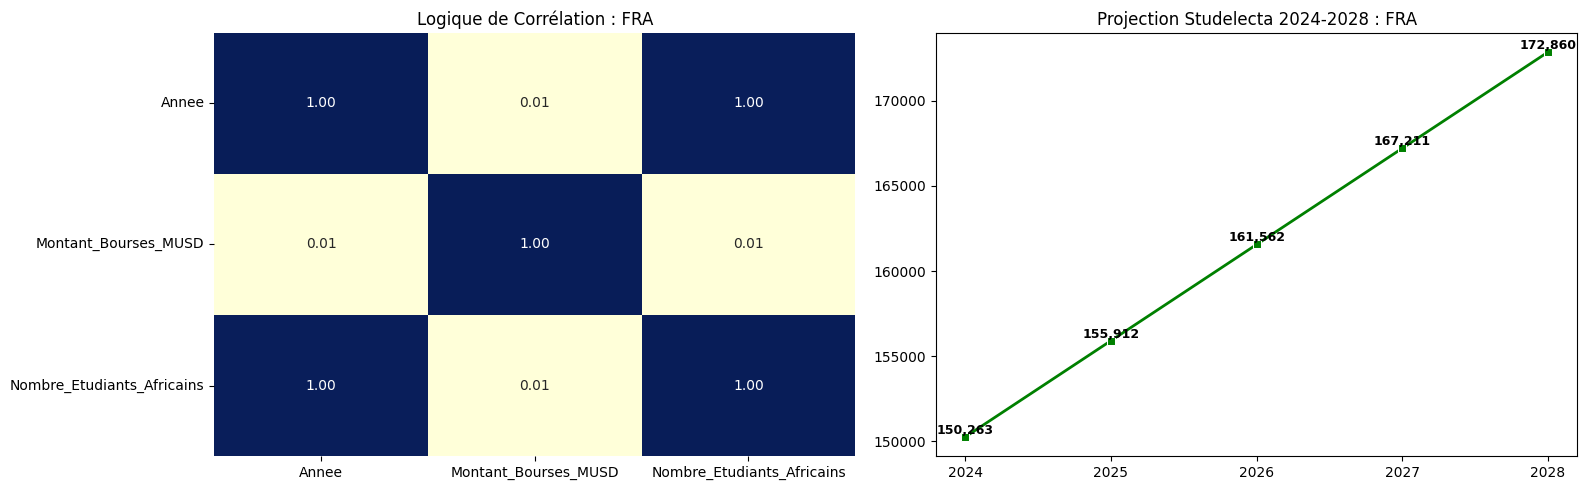

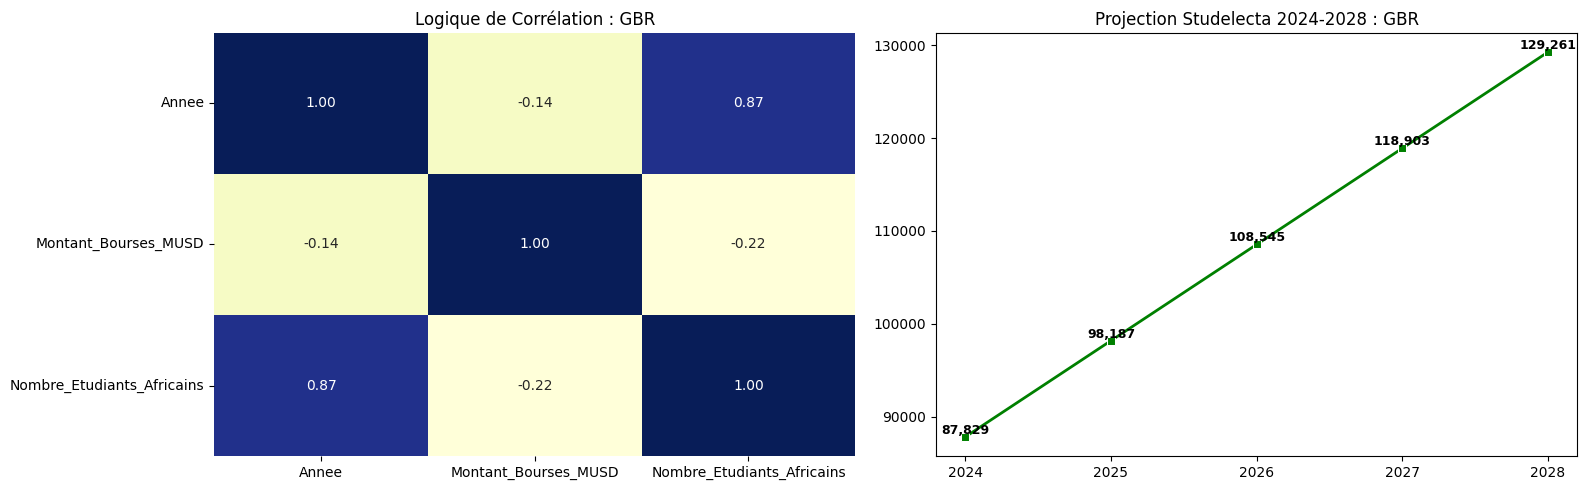

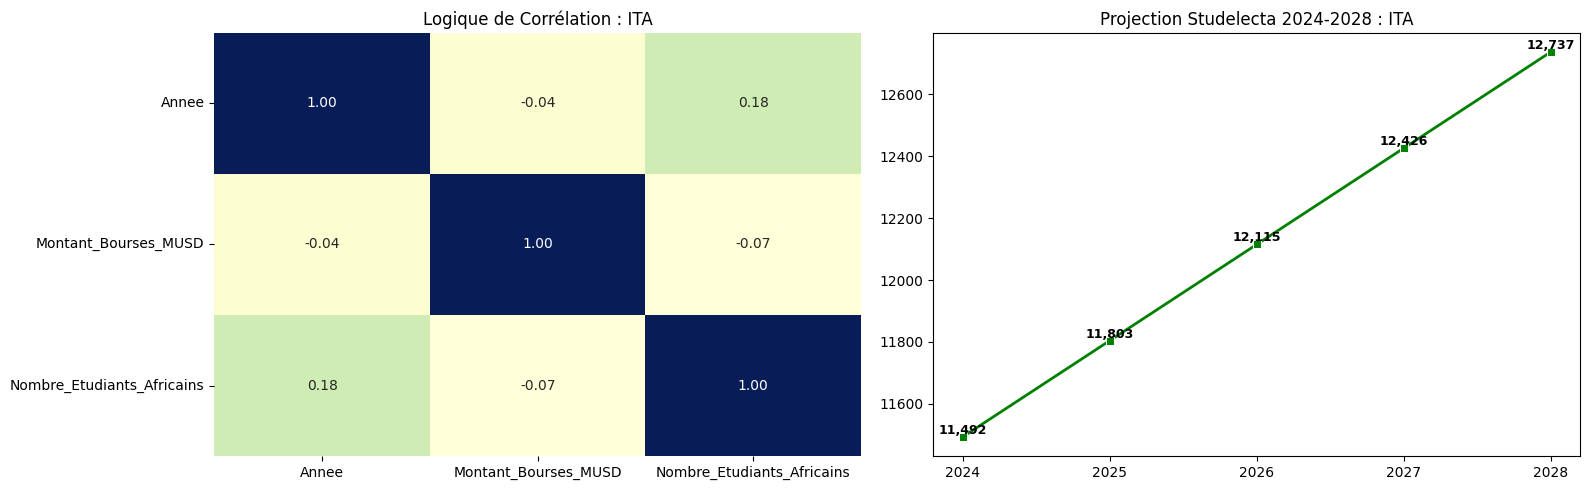

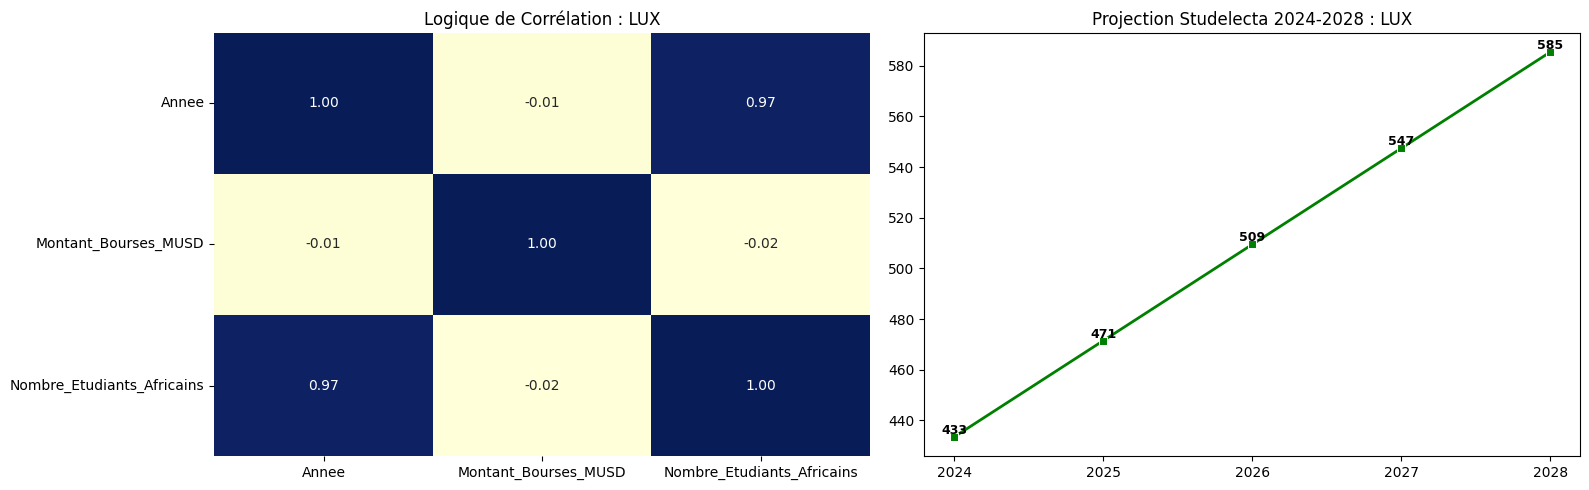


CLASSEMENTS ANNUELS AVEC PROGRESSION (2024-2028)

--- TOP DESTINATIONS 2024 ---
  Pays  Étudiants
1  FRA     150263
2  GBR      87829
3  DEU      46005
4  ITA      11492
5  BEL      10625
6  ESP       7980
7  LUX        433

--- TOP DESTINATIONS 2025 ---
  Pays  Étudiants
1  FRA     155912
2  GBR      98187
3  DEU      49002
4  ITA      11803
5  BEL      11519
6  ESP       8752
7  LUX        471

--- TOP DESTINATIONS 2026 ---
  Pays  Étudiants
1  FRA     161562
2  GBR     108545
3  DEU      51998
4  BEL      12413
5  ITA      12115
6  ESP       9524
7  LUX        509

--- TOP DESTINATIONS 2027 ---
  Pays  Étudiants
1  FRA     167211
2  GBR     118903
3  DEU      54994
4  BEL      13307
5  ITA      12426
6  ESP      10296
7  LUX        547

--- TOP DESTINATIONS 2028 ---
  Pays  Étudiants
1  FRA     172860
2  GBR     129261
3  DEU      57990
4  BEL      14201
5  ITA      12737
6  ESP      11068
7  LUX        585


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Chargement
df = pd.read_csv('Dataset_Studelecta_Final_2026.csv')

# 2. Paramètres
pays_europeens = ['BEL', 'DEU', 'ESP', 'FRA', 'GBR', 'ITA', 'LUX']
annees_futures = [2024, 2025, 2026, 2027, 2028]
resultats_liste = []

# 3. Boucle par pays : Analyse + Prédiction Linéaire (pour l'augmentation)
for code in pays_europeens:
    data_pays = df[df['Code_Destination'] == code].copy()

    # --- PARTIE GAUCHE : CORRÉLATION ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(data_pays[['Annee', 'Montant_Bourses_MUSD', 'Nombre_Etudiants_Africains']].corr(),
                annot=True, cmap='YlGnBu', fmt=".2f", ax=ax1, cbar=False)
    ax1.set_title(f'Logique de Corrélation : {code}')

    # --- PARTIE DROITE : PRÉDICTION LINÉAIRE (Extrapolation) ---
    model = LinearRegression()
    # On apprend la relation entre l'Année et le Nombre d'étudiants
    model.fit(data_pays[['Annee']], data_pays['Nombre_Etudiants_Africains'])

    # Prédiction pour les 5 années suivantes
    futur_X = pd.DataFrame({'Annee': annees_futures})
    preds_futures = model.predict(futur_X)

    # Stockage pour le classement
    for annee, val in zip(annees_futures, preds_futures):
        resultats_liste.append({
            'Année': annee,
            'Pays': code,
            'Étudiants': int(val)
        })

    # Tracé avec une ligne qui monte
    sns.lineplot(x=annees_futures, y=preds_futures, marker='s', ax=ax2, color='green', linewidth=2)
    for x, y in zip(annees_futures, preds_futures):
        ax2.text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2.set_title(f'Projection Studelecta 2024-2028 : {code}')
    ax2.set_xticks(annees_futures)
    plt.tight_layout()
    plt.show()

# 4. CLASSEMENTS ANNUELS (Avec augmentation visible)
df_final = pd.DataFrame(resultats_liste)

print("\n" + "="*60)
print("CLASSEMENTS ANNUELS AVEC PROGRESSION (2024-2028)")
print("="*60)

for annee in annees_futures:
    print(f"\n--- TOP DESTINATIONS {annee} ---")
    top = df_final[df_final['Année'] == annee].sort_values(by='Étudiants', ascending=False)
    top = top.reset_index(drop=True)
    top.index += 1
    print(top[['Pays', 'Étudiants']])